# WEB-transform local error distribution (polygons)

This notebook reproduces the **WEB-transform** workflow from `Neural Analysis/main.py` (assemble standard weighted B-splines → apply Höllig coupling-matrix transform → solve) and then produces the same style of **local error distribution** plots as the collocation study, but for polygon domains:

- Triangle (FUNCTION_CASE = 9)
- Pentagon (FUNCTION_CASE = 10)

All testcases use **homogeneous Dirichlet BC** and the manufactured solution **u_exact = w^2** on the implicit domain Ω = { w(x,y) ≥ 0 }.


In [4]:
import time
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy import sparse

import FEM
import FEM_WEB
import Geomertry
import mesh
import network_defs


# --- Global defaults (tune as needed) ---
DIVISIONS = 50   # like main.py
ORDER = 2        # like main.py
DELTA = 0.005    # like main.py

EXTENSION_METHOD = "collocation"  # matches main.py for WEB-transform
WEB_USE_WEIGHT_NORMALIZATION = True
WEB_REF_WEIGHT_EPS = 1e-10

# Plot controls
N_GRID = 120          # grid resolution for local error plots (keep moderate; reconstruction is expensive)
N_CONTOUR_LEVELS = 24
W_NEAR_MAX = 0.25     # near-boundary band in terms of w (0..W_NEAR_MAX)
N_BINS = 25

# Keep this consistent with assembly/manufactured cases
mesh.TRANSFORM = None


@dataclass
class WebSolveResult:
    name: str
    function_case: int
    model: torch.nn.Module
    p: int
    q: int
    knot_u: np.ndarray
    knot_v: np.ndarray
    x_div: int
    y_div: int
    u_reduced: np.ndarray
    bspline_classification: dict
    extended_basis: dict


def solve_web_transform(
    *,
    name: str,
    function_case: int,
    model: torch.nn.Module,
    divisions: int = DIVISIONS,
    order: int = ORDER,
    delta: float = DELTA,
    extension_method: str = EXTENSION_METHOD,
    web_use_weight_normalization: bool = WEB_USE_WEIGHT_NORMALIZATION,
    web_ref_weight_eps: float = WEB_REF_WEIGHT_EPS,
    ) -> WebSolveResult:
    """Assemble standard weighted B-splines, then apply WEB coupling transform (main.py style)."""
    FEM.set_function_case(function_case)

    default = mesh.getDefaultValues(div=divisions, order=order, delta=delta)
    x0, y0, x1, y1, x_div, y_div, p, q = default

    knot_u, knot_v, _, _ = mesh.generateRectangularMesh(*default)
    assert p == q and x_div == y_div, "This notebook assumes a square tensor mesh (p=q and x_div=y_div)."

    # Init legacy global Bspline cache used by some geometry helpers (mirrors main.py)
    Geomertry.init_spl(np.linspace(x0, x1, 10), p, None, knot_u)

    matrix_size = (x_div + p + 1) * (y_div + q + 1)
    K = sparse.lil_matrix((matrix_size, matrix_size), dtype=np.float64)
    F = np.zeros(matrix_size, dtype=np.float64)

    t0 = time.time()
    K, F, _etype = FEM.processAllElements(model, p, q, knot_u, knot_v, x_div, y_div, K, F)

    K_red, F_red, _etype2, bsp_class, ext_basis, _E = FEM_WEB.transformStandardSystemToWEB(
        K,
        F,
        model,
        p,
        q,
        knot_u,
        knot_v,
        x_div,
        y_div,
        web_use_weight_normalization=web_use_weight_normalization,
        web_ref_weight_eps=web_ref_weight_eps,
        extension_method=extension_method,
    )

    u_red = FEM_WEB.solveWEB(K_red, F_red)
    print(f"[{name}] assembly+transform+solve done in {time.time() - t0:.2f}s | size={len(u_red)}")

    return WebSolveResult(
        name=name,
        function_case=function_case,
        model=model,
        p=p,
        q=q,
        knot_u=knot_u,
        knot_v=knot_v,
        x_div=x_div,
        y_div=y_div,
        u_reduced=u_red,
        bspline_classification=bsp_class,
        extended_basis=ext_basis,
    )


def _eval_w_on_grid(model: torch.nn.Module, X: np.ndarray, Y: np.ndarray) -> np.ndarray:
    """Evaluate w(x,y) on a meshgrid (no derivatives)."""
    pts = np.stack([X.ravel(), Y.ravel()], axis=1)
    crd = torch.tensor(pts, dtype=torch.float64)
    with torch.no_grad():
        w = model(crd).detach().cpu().numpy().reshape(X.shape)
    if mesh.TRANSFORM is not None:
        t = str(mesh.TRANSFORM).lower()
        if t == "sigmoid":
            w = 1.0 / (1.0 + np.exp(-w))
        elif t == "tanh":
            w = np.tanh(w)
        elif t == "logarithmic":
            w = np.log(w + 1.0)
        elif t == "exponential":
            w = np.exp(w) - 1.0
        elif t == "hollig":
            raise NotImplementedError("Plotting w with TRANSFORM='hollig' is not implemented here.")
        else:
            raise NotImplementedError(f"Unsupported mesh.TRANSFORM={mesh.TRANSFORM!r}.")
    return w


def evaluate_error_grid(res: WebSolveResult, *, n: int = N_GRID, margin: float = 0.0):
    """Compute pointwise |u_h - u_ex| on a grid, with masking outside Ω."""
    FEM.set_function_case(res.function_case)

    x = np.linspace(FEM.DOMAIN["x1"] - margin, FEM.DOMAIN["x2"] + margin, n)
    y = np.linspace(FEM.DOMAIN["y1"] - margin, FEM.DOMAIN["y2"] + margin, n)
    X, Y = np.meshgrid(x, y)

    w = _eval_w_on_grid(res.model, X, Y)
    inside = w >= 0.0

    # Manufactured exact: u = w^2
    u_exact = np.full_like(w, np.nan, dtype=np.float64)
    u_exact[inside] = (w[inside] ** 2)

    u_num = np.full_like(w, np.nan, dtype=np.float64)
    inside_idx = np.argwhere(inside)
    for iy, ix in inside_idx:
        xx = float(X[iy, ix])
        yy = float(Y[iy, ix])
        u_num[iy, ix] = FEM_WEB.reconstructSolution(
            xx,
            yy,
            res.u_reduced,
            res.model,
            res.p,
            res.q,
            res.knot_u,
            res.knot_v,
            res.bspline_classification,
            res.extended_basis,
        )

    abs_err = np.abs(u_num - u_exact)

    # Summary metrics on sampled grid (discrete MAE/L_inf like collocation notebook)
    err_mae = float(np.nanmean(abs_err))
    err_linf = float(np.nanmax(abs_err))

    return {
        "x": x,
        "y": y,
        "X": X,
        "Y": Y,
        "w": w,
        "inside": inside,
        "u_exact": u_exact,
        "u_num": u_num,
        "abs_err": abs_err,
        "err_mae": err_mae,
        "err_linf": err_linf,
    }


def bin_errors_by_w(w: np.ndarray, abs_err: np.ndarray, inside: np.ndarray, *, w_max: float, n_bins: int):
    w_in = w[inside]
    e_in = abs_err[inside]

    w_clip = min(float(w_max), float(np.nanmax(w_in)))
    edges = np.linspace(0.0, w_clip, int(n_bins) + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])

    mean_e = np.full(len(centers), np.nan, dtype=np.float64)
    max_e = np.full(len(centers), np.nan, dtype=np.float64)
    counts = np.zeros(len(centers), dtype=int)

    for i in range(len(centers)):
        lo, hi = edges[i], edges[i + 1]
        mask = (w_in >= lo) & (w_in < hi)
        if not np.any(mask):
            continue
        counts[i] = int(np.sum(mask))
        mean_e[i] = float(np.mean(e_in[mask]))
        max_e[i] = float(np.max(e_in[mask]))

    coverage = float(np.sum(counts)) / float(w_in.size) if w_in.size else 0.0
    return {
        "edges": edges,
        "centers": centers,
        "mean": mean_e,
        "max": max_e,
        "counts": counts,
        "coverage": coverage,
        "w_clip": w_clip,
    }


def plot_case(res: WebSolveResult, grid_data: dict, bins: dict):
    X, Y = grid_data["X"], grid_data["Y"]
    abs_err = grid_data["abs_err"]
    w = grid_data["w"]

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # Error heatmap (contourf)
    ax = axes[0]
    cf = ax.contourf(X, Y, abs_err, levels=N_CONTOUR_LEVELS, cmap="hot")
    ax.contour(X, Y, w, levels=[0.0], colors="k", linewidths=1.0)
    fig.colorbar(cf, ax=ax, label="|u_h - u_exact|")
    ax.set_title(f"{res.name}: |error|\nMAE={grid_data['err_mae']:.3e}, L_inf={grid_data['err_linf']:.3e}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)

    # Binned mean + max near boundary
    ax = axes[1]
    ax.plot(bins["centers"], bins["mean"], label="binned mean |error| (MAE)")
    ax.plot(bins["centers"], bins["max"], label="binned max |error| (L_inf)")
    ax.set_title(f"Near-boundary error vs w (0..{bins['w_clip']:.3g})\ncoverage={bins['coverage']:.3f}")
    ax.set_xlabel("w")
    ax.set_ylabel("|u_h - u_exact|")
    ax.grid(True, alpha=0.25)
    ax.legend()

    # Bin counts
    ax = axes[2]
    ax.bar(bins["centers"], bins["counts"], width=(bins["edges"][1] - bins["edges"][0]) * 0.95)
    ax.set_title("Bin sample counts")
    ax.set_xlabel("w")
    ax.set_ylabel("count")
    ax.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()


In [5]:
# --- Define polygon testcases (triangle + pentagon) ---

cases = [
    {
        "name": "Triangle",
        "function_case": 9,
        "model": Geomertry.AnaliticalDistanceTriangle_RFunction(preserve_zero_line=True),
    },
    {
        "name": "Pentagon",
        "function_case": 10,
        "model": Geomertry.AnaliticalDistancePentagon_RFunction(preserve_zero_line=True),
    },
]

solved = {}
for c in cases:
    solved[c["name"]] = solve_web_transform(
        name=c["name"],
        function_case=c["function_case"],
        model=c["model"],
        divisions=DIVISIONS,
        order=ORDER,
        delta=DELTA,
    )

print("Done.")


Processing elements:   0%|          | 0/924 [00:00<?, ?elem/s]

Processing boundary elements: 100%|██████████| 924/924 [00:53<00:00, 17.41elem/s]


Max residual: 3.23e-17
[Triangle] assembly+transform+solve done in 53.34s | size=920


Processing boundary elements: 100%|██████████| 1313/1313 [01:38<00:00, 13.31elem/s]


Max residual: 3.01e-17
[Pentagon] assembly+transform+solve done in 99.18s | size=1309
Done.



Plotting: Triangle


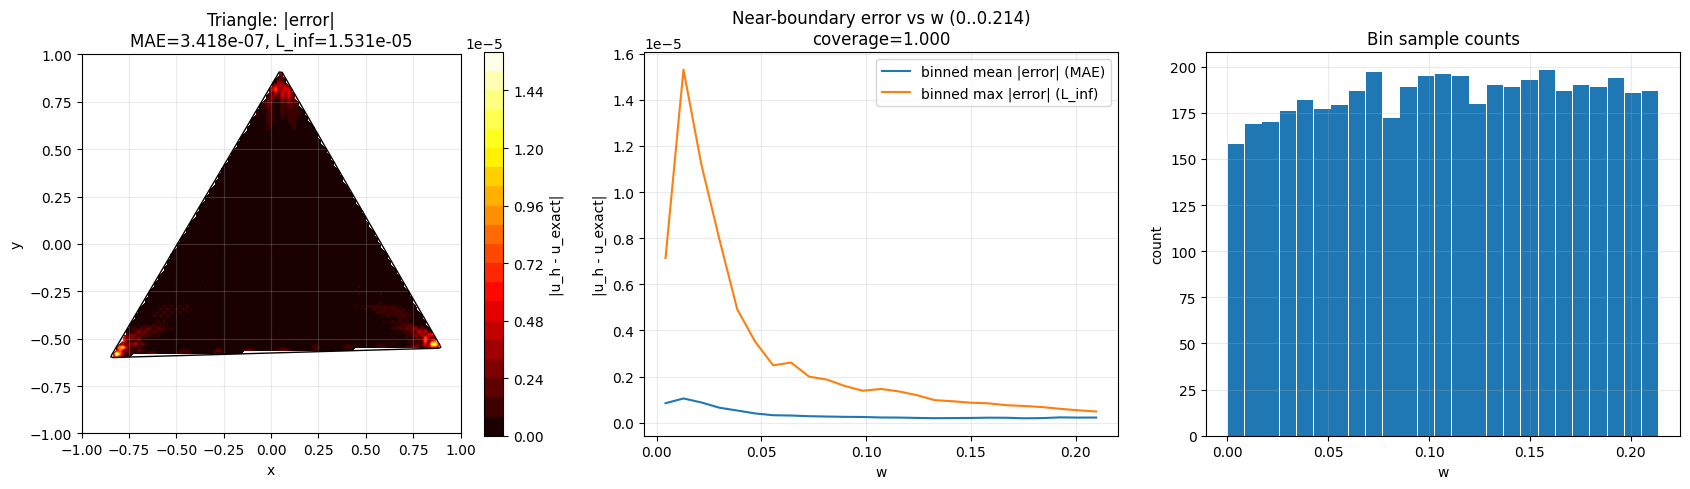


Plotting: Pentagon


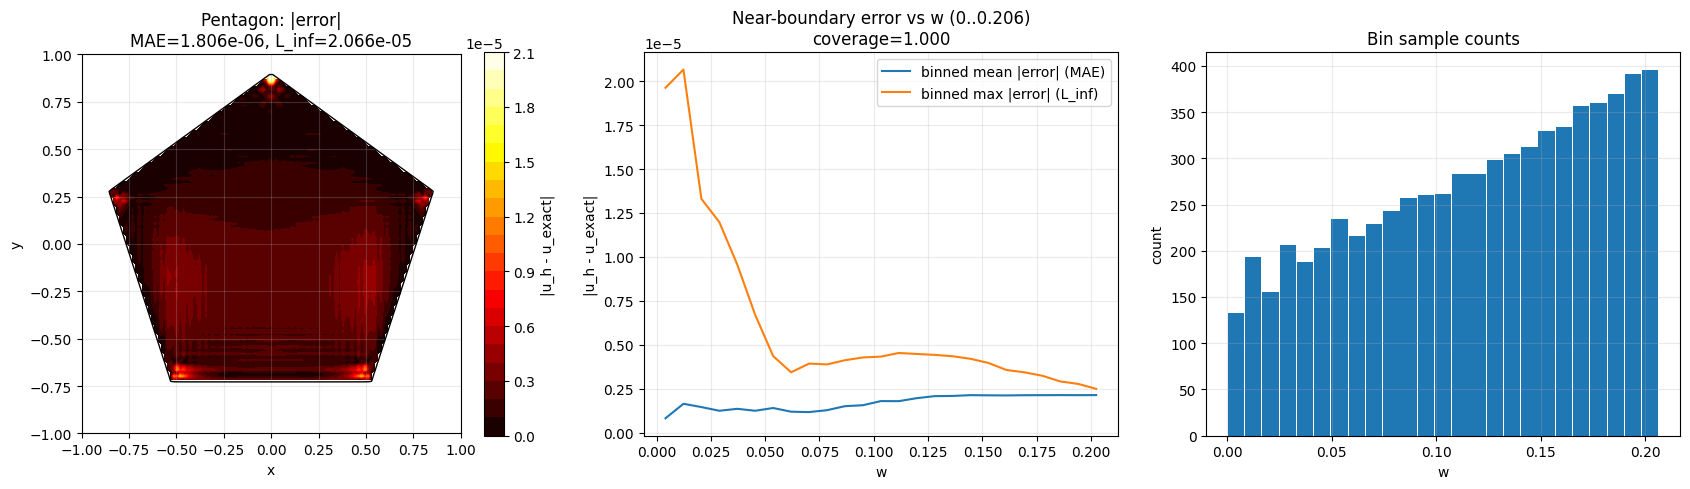

In [6]:
# --- Local error distribution plots (heatmap + binned near-boundary curves + bin counts) ---

grid_by_case = {}
bins_by_case = {}

for name, res in solved.items():
    print(f"\nPlotting: {name}")
    g = evaluate_error_grid(res, n=N_GRID, margin=0.0)
    b = bin_errors_by_w(g["w"], g["abs_err"], g["inside"], w_max=W_NEAR_MAX, n_bins=N_BINS)
    grid_by_case[name] = g
    bins_by_case[name] = b
    plot_case(res, g, b)


In [36]:
# --- PDE-residual correction via random-point collocation (L1 residual) ---

# We train a correction on random interior points:
#   u(x,y) = u_web(x,y) + corr(x,y)
#   corr(x,y) = w_+(x,y) * exp(-alpha*w_+(x,y)) * phi(feats(x,y))
# where feats(x,y) contains, for each polygon edge i:
#   - distance d_i(x,y) to the i-th edge segment
#   - sweep parameter s_i(x,y) in [0,1], the projection parameter along that segment
#     (i.e. closest-point projection onto the segment)
# Loss (L1):
#   L = mean( | -Δ(u_web + corr) - f | )
#
# Implementation notes:
# - We sample points from the existing evaluation grid (random subset), which makes
#   B-spline evaluation fast and stable (finite set of x/y coordinates).
# - Δ(corr) is computed by autograd.
# - Δ(u_web) is computed analytically from the WEB basis + w-derivatives.
# - For this manufactured test (u_exact=w^2 available), we monitor metrics on a
#   deterministic eval set and keep the best model state.

import time
from typing import Optional, Tuple

import numpy as np
import torch

import FEM
import FEM_WEB
import mesh
import network_defs


def _torch_distance_and_sweep_point_to_segment(px, py, x1, y1, x2, y2, eps=None):
    """Vectorized distance + sweep parameter t in [0,1] for projection onto segment."""
    if eps is None:
        eps = torch.finfo(px.dtype).eps
    x1 = float(x1)
    y1 = float(y1)
    x2 = float(x2)
    y2 = float(y2)

    dx = x2 - x1
    dy = y2 - y1
    line_len_sq = dx * dx + dy * dy
    if line_len_sq == 0.0:
        dist = torch.sqrt((px - x1) ** 2 + (py - y1) ** 2 + eps)
        t = torch.zeros_like(dist)
        return dist, t

    t = ((px - x1) * dx + (py - y1) * dy) / line_len_sq
    t = torch.clamp(t, 0.0, 1.0)
    proj_x = x1 + t * dx
    proj_y = y1 + t * dy
    dist = torch.sqrt((px - proj_x) ** 2 + (py - proj_y) ** 2 + eps)
    return dist, t


def polygon_side_distance_and_sweep_points_torch(
    coords_xy: torch.Tensor, vertices_ccw_np: np.ndarray
) -> Tuple[torch.Tensor, torch.Tensor]:
    """Return per-edge distances and sweeps for each point in coords_xy (N,2)."""
    v = np.asarray(vertices_ccw_np, dtype=np.float64)
    m = v.shape[0]
    px = coords_xy[:, 0]
    py = coords_xy[:, 1]
    dists = []
    sweeps = []
    for i in range(m):
        x1, y1 = v[i, 0], v[i, 1]
        x2, y2 = v[(i + 1) % m, 0], v[(i + 1) % m, 1]
        d, t = _torch_distance_and_sweep_point_to_segment(px, py, x1, y1, x2, y2)
        dists.append(d)
        sweeps.append(t)
    return torch.stack(dists, dim=1), torch.stack(sweeps, dim=1)  # (N,m), (N,m)


def polygon_side_features_points_torch(
    coords_xy: torch.Tensor,
    vertices_ccw_np: np.ndarray,
    *,
    dist_scale: float,
    sweep_centered: bool = True,
) -> torch.Tensor:
    """Feature vector per point: [d_1..d_m, s_1..s_m] with scaling."""
    d, s = polygon_side_distance_and_sweep_points_torch(coords_xy, vertices_ccw_np)
    d = d / float(dist_scale)
    if sweep_centered:
        s = 2.0 * s - 1.0  # map [0,1] -> [-1,1]
    return torch.cat([d, s], dim=1)  # (N, 2m)


def _zero_init_last_layer(net: torch.nn.Module) -> None:
    """Make the network output identically 0 at initialization."""
    if hasattr(net, "net") and isinstance(net.net, torch.nn.Sequential):
        for layer in reversed(net.net):
            if isinstance(layer, torch.nn.Linear):
                torch.nn.init.zeros_(layer.weight)
                if layer.bias is not None:
                    torch.nn.init.zeros_(layer.bias)
                return

    for layer in reversed(list(net.modules())):
        if isinstance(layer, torch.nn.Linear):
            torch.nn.init.zeros_(layer.weight)
            if layer.bias is not None:
                torch.nn.init.zeros_(layer.bias)
            return


def _make_correction_net(
    *,
    net_type: str,
    in_dim: int,
    hidden: int,
    layers: int,
    first_omega_0: float,
    hidden_omega_0: float,
    device: str,
):
    t = str(net_type).strip().lower()
    arch = [int(in_dim)] + [int(hidden)] * int(layers) + [1]
    if t == "siren":
        net = network_defs.Siren(
            architecture=arch,
            outermost_linear=True,
            first_omega_0=first_omega_0,
            hidden_omega_0=hidden_omega_0,
        ).double().to(device)
        _zero_init_last_layer(net)
        return net

    if t in ("relu", "nn", "neuralnetwork"):
        net = network_defs.NeuralNetwork(architecture=arch).double().to(device)
        _zero_init_last_layer(net)
        return net

    raise ValueError(f"Unknown net_type={net_type!r}. Use 'SIREN' or 'ReLU'.")


def _precompute_1d_basis_and_derivs(B, xs: np.ndarray, max_order: int = 2):
    """Precompute B(x), B'(x), B''(x) for all x in xs."""
    B0 = [B(float(x)) for x in xs]
    B1 = [B.diff(1)(float(x)) for x in xs] if max_order >= 1 else None
    B2 = [B.diff(2)(float(x)) for x in xs] if max_order >= 2 else None
    return (
        np.asarray(B0, dtype=np.float64),
        np.asarray(B1, dtype=np.float64) if B1 is not None else None,
        np.asarray(B2, dtype=np.float64) if B2 is not None else None,
    )


def _web_sum_and_derivs_from_precomputed(
    res: WebSolveResult,
    *,
    bx: np.ndarray,
    dbx: np.ndarray,
    ddbx: np.ndarray,
    by: np.ndarray,
    dby: np.ndarray,
    ddby: np.ndarray,
    ix: int,
    iy: int,
):
    """Compute S, Sx, Sy, Sxx, Syy for S(x,y) = Σ u_i * Be_i(x,y) at grid index (iy,ix)."""
    bxi = bx[ix]
    beta = by[iy]
    dbxi = dbx[ix]
    dbeta = dby[iy]
    ddbxi = ddbx[ix]
    ddbeta = ddby[iy]

    n_basis_x = res.bspline_classification["n_basis_x"]
    n_basis_y = res.bspline_classification["n_basis_y"]
    inner_bsplines = res.bspline_classification["inner"]

    use_norm = bool(res.bspline_classification.get("web_use_weight_normalization", False))
    ref_weights = res.bspline_classification.get("inner_reference_weights") if use_norm else None

    S = 0.0
    Sx = 0.0
    Sy = 0.0
    Sxx = 0.0
    Syy = 0.0

    for reduced_idx, inner_idx in enumerate(inner_bsplines):
        coeff = float(res.u_reduced[reduced_idx])
        basis_coeffs = res.extended_basis[inner_idx]

        Be = 0.0
        Be_x = 0.0
        Be_y = 0.0
        Be_xx = 0.0
        Be_yy = 0.0

        for (bi, bj), ecoeff in basis_coeffs.items():
            if bi < n_basis_x and bj < n_basis_y:
                e = float(ecoeff)
                bxv = float(bxi[bi])
                byv = float(beta[bj])
                dbxv = float(dbxi[bi])
                dbyv = float(dbeta[bj])
                ddbxv = float(ddbxi[bi])
                ddbyv = float(ddbeta[bj])

                Be += e * bxv * byv
                Be_x += e * dbxv * byv
                Be_y += e * bxv * dbyv
                Be_xx += e * ddbxv * byv
                Be_yy += e * bxv * ddbyv

        if use_norm:
            w_i = ref_weights.get(inner_idx) if ref_weights is not None else None
            if w_i is None:
                raise RuntimeError(
                    "WEB normalization enabled but missing w(x_i) for inner index " f"{inner_idx}."
                )
            inv_w = 1.0 / float(w_i)
            Be *= inv_w
            Be_x *= inv_w
            Be_y *= inv_w
            Be_xx *= inv_w
            Be_yy *= inv_w

        S += coeff * Be
        Sx += coeff * Be_x
        Sy += coeff * Be_y
        Sxx += coeff * Be_xx
        Syy += coeff * Be_yy

    return S, Sx, Sy, Sxx, Syy


def train_residual_correction_random_points(
    res: WebSolveResult,
    grid_for_eval: dict,
    *,
    net_type: str = "SIREN",
    iters: int = 250,
    lr: float = 1e-4,
    hidden: int = 64,
    layers: int = 2,
    first_omega_0: float = 30.0,
    hidden_omega_0: float = 30.0,
    dist_scale: float = 2.0,
    batch_size: int = 128,
    w_min: float = 1e-4,
    boundary_alpha: float = 80.0,
    sample_beta: float = 80.0,
    corr_l2: float = 0.0,
    eval_every: int = 25,
    eval_n: int = 0,
    select_by: str = "linf_mae",  # 'linf_mae' or 'mae_linf'
    grad_clip: float = 1.0,
    device: str = "cpu",
    verbose_every: int = 100,
    seed: Optional[int] = 0,
    init_state_dict: Optional[dict] = None,
):
    FEM.set_function_case(res.function_case)
    FEM.ACTIVE_MODEL = res.model

    if seed is not None:
        np.random.seed(int(seed))
        torch.manual_seed(int(seed))

    if not hasattr(res.model, "_vertices_np"):
        raise AttributeError("Expected polygon geometry model to have _vertices_np (triangle/pentagon).")
    verts = res.model._vertices_np

    n_sides = int(np.asarray(verts).shape[0])
    in_dim = 2 * n_sides
    phi = _make_correction_net(
        net_type=net_type,
        in_dim=in_dim,
        hidden=hidden,
        layers=layers,
        first_omega_0=first_omega_0,
        hidden_omega_0=hidden_omega_0,
        device=device,
    )
    if init_state_dict is not None:
        phi.load_state_dict(init_state_dict)

    opt = torch.optim.Adam(phi.parameters(), lr=float(lr))

    inside = grid_for_eval["inside"]
    w_grid = grid_for_eval["w"]
    X_grid = grid_for_eval["X"]
    Y_grid = grid_for_eval["Y"]

    valid = inside & (w_grid >= float(w_min))
    valid_idx = np.argwhere(valid)
    valid_w = w_grid[valid] if np.any(valid) else None
    if valid_idx.shape[0] < batch_size:
        valid_idx = np.argwhere(inside)
        valid_w = w_grid[inside]

    if valid_w is None or valid_idx.shape[0] == 0:
        raise RuntimeError("No valid interior points to sample for correction training.")

    if float(sample_beta) > 0.0:
        weights = np.exp(-float(sample_beta) * np.asarray(valid_w, dtype=np.float64))
        weights = weights / np.sum(weights)
    else:
        weights = None

    # Precompute 1D basis values/derivatives for x/y coordinates.
    Bspxi, Bspeta = FEM._get_bspline_objects(res.knot_u, res.knot_v, res.p, res.q)
    if "x" in grid_for_eval and "y" in grid_for_eval:
        x_vals = np.asarray(grid_for_eval["x"], dtype=np.float64)
        y_vals = np.asarray(grid_for_eval["y"], dtype=np.float64)
    else:
        x_vals = np.asarray(X_grid[0, :], dtype=np.float64)
        y_vals = np.asarray(Y_grid[:, 0], dtype=np.float64)

    bx, dbx, ddbx = _precompute_1d_basis_and_derivs(Bspxi, x_vals, max_order=2)
    by, dby, ddby = _precompute_1d_basis_and_derivs(Bspeta, y_vals, max_order=2)

    # Eval set: deterministic and (by default) full inside grid, so selection is stable.
    u_web_grid = np.nan_to_num(grid_for_eval.get("u_num"), nan=0.0)
    u_exact_grid = grid_for_eval.get("u_exact")

    best_state = None
    best_key = None

    if u_exact_grid is not None and bool(eval_every):
        eval_idx = np.argwhere(inside)
        if int(eval_n) > 0 and eval_idx.shape[0] > int(eval_n):
            # deterministic subsample: take every k-th point
            step = max(1, int(eval_idx.shape[0] // int(eval_n)))
            eval_idx = eval_idx[::step][: int(eval_n)]

        eval_iy = eval_idx[:, 0]
        eval_ix = eval_idx[:, 1]
        u_web_eval = u_web_grid[eval_iy, eval_ix]
        u_exact_eval = u_exact_grid[eval_iy, eval_ix]
        coords_eval = torch.tensor(
            np.stack([X_grid[eval_iy, eval_ix], Y_grid[eval_iy, eval_ix]], axis=1),
            dtype=torch.float64,
            device=device,
        )
        with torch.no_grad():
            feats_eval_fixed = polygon_side_features_points_torch(
                coords_eval, verts, dist_scale=dist_scale, sweep_centered=True
            )
    else:
        coords_eval = None
        feats_eval_fixed = None

    def sample_batch_indices(n: int):
        sel = np.random.choice(valid_idx.shape[0], size=int(n), replace=False, p=weights)
        pts = valid_idx[sel]
        iy = pts[:, 0]
        ix = pts[:, 1]
        return ix, iy

    def laplacian_via_autograd(scalar_field: torch.Tensor, coords: torch.Tensor) -> torch.Tensor:
        grad = torch.autograd.grad(
            outputs=scalar_field,
            inputs=coords,
            grad_outputs=torch.ones_like(scalar_field),
            create_graph=True,
            retain_graph=True,
        )[0]
        d2x = torch.autograd.grad(
            outputs=grad[:, 0],
            inputs=coords,
            grad_outputs=torch.ones_like(grad[:, 0]),
            create_graph=True,
            retain_graph=True,
        )[0][:, 0]
        d2y = torch.autograd.grad(
            outputs=grad[:, 1],
            inputs=coords,
            grad_outputs=torch.ones_like(grad[:, 1]),
            create_graph=True,
            retain_graph=True,
        )[0][:, 1]
        return d2x + d2y

    def make_corr(coords_in: torch.Tensor, feats_in: torch.Tensor) -> torch.Tensor:
        w_t = res.model(coords_in).view(-1)
        w_pos = torch.clamp(w_t, min=0.0)
        phi_val = phi(feats_in).view(-1)
        if float(boundary_alpha) > 0.0:
            env = torch.exp(-float(boundary_alpha) * w_pos)
        else:
            env = 1.0
        return w_pos * env * phi_val

    def key_from_metrics(mae: float, linf: float):
        if str(select_by).lower() == "mae_linf":
            return (mae, linf)
        return (linf, mae)

    t0 = time.time()
    for it in range(1, int(iters) + 1):
        ix, iy = sample_batch_indices(batch_size)
        xs = X_grid[iy, ix]
        ys = Y_grid[iy, ix]

        w, wx, wy, wxx, wyy = FEM._eval_weight_and_hessian_diag_np(xs, ys, FEM.ACTIVE_MODEL, transform=mesh.TRANSFORM)

        g = FEM.dirichletBoundary_vectorized(xs, ys)
        gx = FEM.dirichletBoundaryDerivativeX_vectorized(xs, ys)
        gy = FEM.dirichletBoundaryDerivativeY_vectorized(xs, ys)
        gxx = FEM.dirichletBoundaryDerivativeXX_vectorized(xs, ys)
        gyy = FEM.dirichletBoundaryDerivativeYY_vectorized(xs, ys)

        S = np.zeros_like(xs, dtype=np.float64)
        Sx = np.zeros_like(xs, dtype=np.float64)
        Sy = np.zeros_like(xs, dtype=np.float64)
        Sxx = np.zeros_like(xs, dtype=np.float64)
        Syy = np.zeros_like(xs, dtype=np.float64)

        for k in range(xs.size):
            s, sx, sy, sxx, syy = _web_sum_and_derivs_from_precomputed(
                res,
                bx=bx,
                dbx=dbx,
                ddbx=ddbx,
                by=by,
                dby=dby,
                ddby=ddby,
                ix=int(ix[k]),
                iy=int(iy[k]),
            )
            S[k] = s
            Sx[k] = sx
            Sy[k] = sy
            Sxx[k] = sxx
            Syy[k] = syy

        u_xx = wxx * (S - g) + 2.0 * wx * (Sx - gx) + w * Sxx + (1.0 - w) * gxx
        u_yy = wyy * (S - g) + 2.0 * wy * (Sy - gy) + w * Syy + (1.0 - w) * gyy
        lap_u_web = u_xx + u_yy

        f_np = FEM.load_function_vectorized(xs, ys)

        coords = torch.tensor(np.stack([xs, ys], axis=1), dtype=torch.float64, device=device, requires_grad=True)
        lap_u_web_t = torch.tensor(lap_u_web, dtype=torch.float64, device=device)
        f_t = torch.tensor(f_np, dtype=torch.float64, device=device)

        feats = polygon_side_features_points_torch(coords, verts, dist_scale=dist_scale, sweep_centered=True)
        corr = make_corr(coords, feats)
        lap_corr = laplacian_via_autograd(corr, coords)

        resid = -(lap_u_web_t + lap_corr) - f_t
        loss = torch.mean(torch.abs(resid))
        if float(corr_l2) > 0.0:
            loss = loss + float(corr_l2) * torch.mean(corr * corr)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        if float(grad_clip) > 0.0:
            torch.nn.utils.clip_grad_norm_(phi.parameters(), max_norm=float(grad_clip))
        opt.step()

        if verbose_every and (it % int(verbose_every) == 0 or it == 1 or it == int(iters)):
            with torch.no_grad():
                print(f"[{res.name}] it={it:4d}/{iters} | L1(resid)={loss.item():.3e}")

        if coords_eval is not None and eval_every and (it % int(eval_every) == 0 or it == 1 or it == int(iters)):
            with torch.no_grad():
                corr_eval = make_corr(coords_eval, feats_eval_fixed).cpu().numpy()
            u_pred = u_web_eval + corr_eval
            e = np.abs(u_pred - u_exact_eval)
            mae = float(np.mean(e))
            linf = float(np.max(e))
            k = key_from_metrics(mae, linf)
            if best_key is None or k < best_key:
                best_key = k
                best_state = {kk: vv.detach().cpu().clone() for kk, vv in phi.state_dict().items()}

    dt = time.time() - t0
    print(f"[{res.name}] random-point training done in {dt:.1f}s")
    if best_state is not None:
        phi.load_state_dict(best_state)

    # Evaluate correction on full grid for plots
    X_grid_t = torch.tensor(X_grid, dtype=torch.float64, device=device)
    Y_grid_t = torch.tensor(Y_grid, dtype=torch.float64, device=device)
    pts = torch.stack([X_grid_t.reshape(-1), Y_grid_t.reshape(-1)], dim=1)
    with torch.no_grad():
        feats_g = polygon_side_features_points_torch(pts, verts, dist_scale=dist_scale, sweep_centered=True)
        corr_g = make_corr(pts, feats_g).view_as(X_grid_t)

    u_corr_grid = u_web_grid + corr_g.cpu().numpy()

    return {
        "net_type": str(net_type),
        "phi": phi,
        "u_corrected": u_corr_grid,
        "corr": corr_g.cpu().numpy(),
        "best_key": best_key,
    }


# Ensure we have grid data available
if "grid_by_case" not in globals():
    grid_by_case = {}
    for name, res in solved.items():
        print(f"Computing grid for: {name} (needed for residual training)")
        grid_by_case[name] = evaluate_error_grid(res, n=N_GRID, margin=0.0)


def _metrics_on_inside(u: np.ndarray, u_exact: np.ndarray, inside: np.ndarray):
    err = np.abs(u - u_exact)
    e = err[inside]
    return float(np.mean(e)), float(np.max(e))


# --- Hyperparameter sweep ---
# Targeted sweep: include higher-omega SIREN.
# Selection policy:
# - Prefer configs that improve L_inf but do not worsen MAE beyond a tolerance.
# - If none satisfy the MAE guardrail, fall back to pure (L_inf, MAE) selection.
# - After selecting best, do a short fine-tune run at smaller LR.
DIST_SCALE = 2.0
BASE_ITERS = 240
BASE_BATCH = 128
BASE_W_MIN = 1e-4
EVAL_EVERY = 25
EVAL_N = 0  # 0 => use full inside grid for deterministic selection
GRAD_CLIP = 1.0
SELECT_BY = "linf_mae"

MAE_GUARD_TOL = 0.02  # allow up to +2% MAE vs baseline

BOUNDARY_ALPHA = 120.0
SAMPLE_BETA = 120.0

SWEEP_SEED = 0

# Fine-tune settings (one extra training run per case)
FINE_TUNE_ITERS = 120

SWEEP_CONFIGS = [
    # ReLU
    dict(net_type="ReLU", lr=1e-4, hidden=128, layers=3, corr_l2=1e-6),
    dict(net_type="ReLU", lr=5e-5, hidden=128, layers=4, corr_l2=1e-6),
    # SIREN (vary omega)
    dict(net_type="SIREN", lr=5e-5, hidden=64, layers=2, first_omega_0=30.0, hidden_omega_0=30.0, corr_l2=1e-6),
    dict(net_type="SIREN", lr=2e-5, hidden=64, layers=2, first_omega_0=60.0, hidden_omega_0=60.0, corr_l2=1e-6),
    dict(net_type="SIREN", lr=1e-5, hidden=64, layers=2, first_omega_0=90.0, hidden_omega_0=90.0, corr_l2=1e-6),
    dict(net_type="SIREN", lr=1e-5, hidden=64, layers=2, first_omega_0=120.0, hidden_omega_0=120.0, corr_l2=1e-6),
    # Boundary focusing variants
    dict(net_type="SIREN", lr=2e-5, hidden=64, layers=2, first_omega_0=60.0, hidden_omega_0=60.0, corr_l2=1e-6, boundary_alpha=80.0, sample_beta=200.0),
    dict(net_type="SIREN", lr=2e-5, hidden=64, layers=2, first_omega_0=60.0, hidden_omega_0=60.0, corr_l2=1e-6, boundary_alpha=160.0, sample_beta=200.0),
]


corr_models = {}
corr_results = {}

for name, res in solved.items():
    g = grid_by_case[name]
    inside = g["inside"]
    u_exact = g["u_exact"]

    u_before = np.nan_to_num(g["u_num"], nan=0.0)
    base_mae, base_linf = _metrics_on_inside(u_before, u_exact, inside)
    print(f"\n[{name}] baseline MAE={base_mae:.3e} | L_inf={base_linf:.3e}")

    best_out_overall = None
    best_pair_overall = None

    best_out_guarded = None
    best_pair_guarded = None

    for cfg in SWEEP_CONFIGS:
        cfg_disp = {k: cfg[k] for k in sorted(cfg.keys())}
        print(f"  -> training cfg={cfg_disp}")

        out = train_residual_correction_random_points(
            res,
            g,
            net_type=cfg.get("net_type", "SIREN"),
            iters=int(cfg.get("iters", BASE_ITERS)),
            lr=float(cfg.get("lr", 1e-4)),
            hidden=int(cfg.get("hidden", 64)),
            layers=int(cfg.get("layers", 2)),
            first_omega_0=float(cfg.get("first_omega_0", 30.0)),
            hidden_omega_0=float(cfg.get("hidden_omega_0", 30.0)),
            dist_scale=float(cfg.get("dist_scale", DIST_SCALE)),
            batch_size=int(cfg.get("batch_size", BASE_BATCH)),
            w_min=float(cfg.get("w_min", BASE_W_MIN)),
            boundary_alpha=float(cfg.get("boundary_alpha", BOUNDARY_ALPHA)),
            sample_beta=float(cfg.get("sample_beta", SAMPLE_BETA)),
            corr_l2=float(cfg.get("corr_l2", 0.0)),
            eval_every=int(cfg.get("eval_every", EVAL_EVERY)),
            eval_n=int(cfg.get("eval_n", EVAL_N)),
            select_by=str(cfg.get("select_by", SELECT_BY)),
            grad_clip=float(cfg.get("grad_clip", GRAD_CLIP)),
            device="cpu",
            verbose_every=100,
            seed=SWEEP_SEED,
        )

        mae, linf = _metrics_on_inside(out["u_corrected"], u_exact, inside)
        print(f"     cfg result: MAE={mae:.3e} | L_inf={linf:.3e}")

        pair = (linf, mae) if SELECT_BY == "linf_mae" else (mae, linf)

        if best_pair_overall is None or pair < best_pair_overall:
            best_pair_overall = pair
            best_out_overall = out

        if mae <= base_mae * (1.0 + float(MAE_GUARD_TOL)):
            if best_pair_guarded is None or pair < best_pair_guarded:
                best_pair_guarded = pair
                best_out_guarded = out

    best_out = best_out_guarded if best_out_guarded is not None else best_out_overall

    # Fine-tune the selected model for a bit (smaller LR)
    if FINE_TUNE_ITERS > 0:
        ft_lr = 1e-5
        if best_out["net_type"].lower() == "relu":
            ft_lr = 3e-5

        print(f"[{name}] fine-tuning selected model: iters={FINE_TUNE_ITERS}, lr={ft_lr:.2e}")
        ft_state = {k: v.detach().cpu().clone() for k, v in best_out["phi"].state_dict().items()}

        ft_out = train_residual_correction_random_points(
            res,
            g,
            net_type=best_out["net_type"],
            iters=int(FINE_TUNE_ITERS),
            lr=float(ft_lr),
            hidden=64 if best_out["net_type"].lower() == "siren" else 128,
            layers=2 if best_out["net_type"].lower() == "siren" else 3,
            first_omega_0=60.0,
            hidden_omega_0=60.0,
            dist_scale=float(DIST_SCALE),
            batch_size=int(BASE_BATCH),
            w_min=float(BASE_W_MIN),
            boundary_alpha=float(BOUNDARY_ALPHA),
            sample_beta=float(SAMPLE_BETA),
            corr_l2=1e-6,
            eval_every=int(EVAL_EVERY),
            eval_n=int(EVAL_N),
            select_by=str(SELECT_BY),
            grad_clip=float(GRAD_CLIP),
            device="cpu",
            verbose_every=100,
            seed=SWEEP_SEED,
            init_state_dict=ft_state,
        )

        mae_ft, linf_ft = _metrics_on_inside(ft_out["u_corrected"], u_exact, inside)
        mae_best, linf_best = _metrics_on_inside(best_out["u_corrected"], u_exact, inside)

        accept = False
        if mae_ft <= base_mae * (1.0 + float(MAE_GUARD_TOL)):
            accept = (linf_ft, mae_ft) < (linf_best, mae_best)

        if accept:
            print(f"[{name}] fine-tune accepted: MAE={mae_best:.3e}->{mae_ft:.3e} | L_inf={linf_best:.3e}->{linf_ft:.3e}")
            best_out = ft_out
        else:
            print(f"[{name}] fine-tune rejected: MAE={mae_ft:.3e} | L_inf={linf_ft:.3e}")

    corr_models[name] = best_out["phi"]
    corr_results[name] = best_out
    mae_best, linf_best = _metrics_on_inside(best_out["u_corrected"], u_exact, inside)
    if best_out_guarded is not None:
        print(f"[{name}] best (guarded) MAE={mae_best:.3e} | L_inf={linf_best:.3e}")
    else:
        print(f"[{name}] best (fallback) MAE={mae_best:.3e} | L_inf={linf_best:.3e}")

print("Done training corrections (distance+sweep features + guarded selection + fine-tune).")



[Triangle] baseline MAE=3.418e-07 | L_inf=1.531e-05
  -> training cfg={'corr_l2': 1e-06, 'hidden': 128, 'layers': 3, 'lr': 0.0001, 'net_type': 'ReLU'}
[Triangle] it=   1/240 | L1(resid)=3.324e-02
[Triangle] it= 100/240 | L1(resid)=3.376e-02
[Triangle] it= 200/240 | L1(resid)=3.074e-02
[Triangle] it= 240/240 | L1(resid)=3.541e-02
[Triangle] random-point training done in 76.5s
     cfg result: MAE=4.190e-07 | L_inf=1.376e-05
  -> training cfg={'corr_l2': 1e-06, 'hidden': 128, 'layers': 4, 'lr': 5e-05, 'net_type': 'ReLU'}
[Triangle] it=   1/240 | L1(resid)=3.324e-02
[Triangle] it= 100/240 | L1(resid)=3.495e-02
[Triangle] it= 200/240 | L1(resid)=3.451e-02
[Triangle] it= 240/240 | L1(resid)=3.555e-02
[Triangle] random-point training done in 74.5s
     cfg result: MAE=3.498e-07 | L_inf=1.468e-05
  -> training cfg={'corr_l2': 1e-06, 'first_omega_0': 30.0, 'hidden': 64, 'hidden_omega_0': 30.0, 'layers': 2, 'lr': 5e-05, 'net_type': 'SIREN'}
[Triangle] it=   1/240 | L1(resid)=3.324e-02
[Triangl

Triangle: MAE 3.418e-07 -> 6.786e-07 | L_inf 1.531e-05 -> 1.303e-05
Pentagon: MAE 1.806e-06 -> 1.829e-06 | L_inf 2.066e-05 -> 1.625e-05


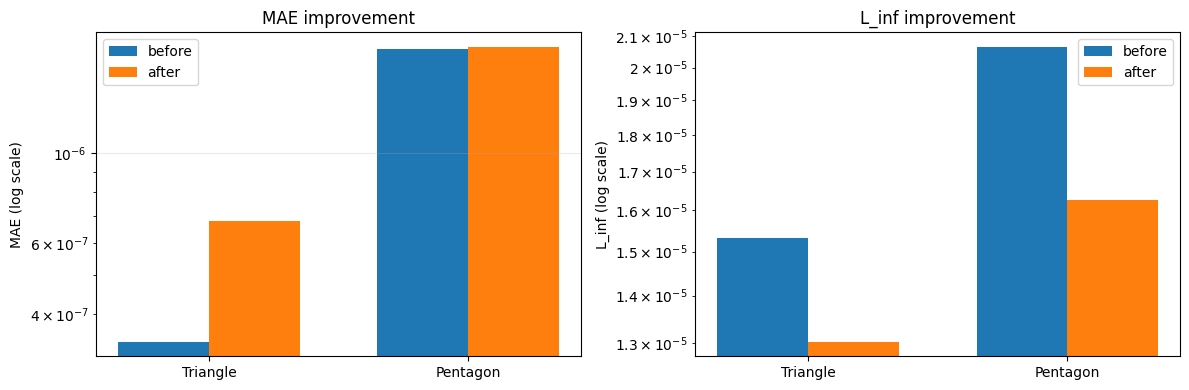

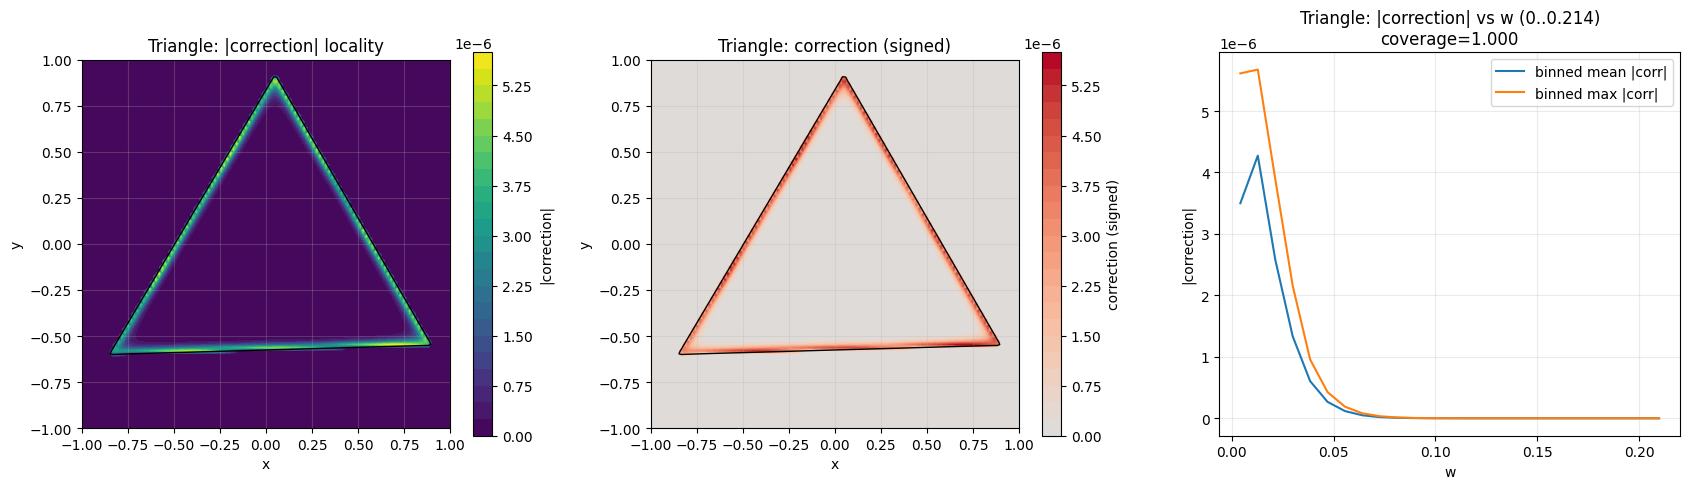

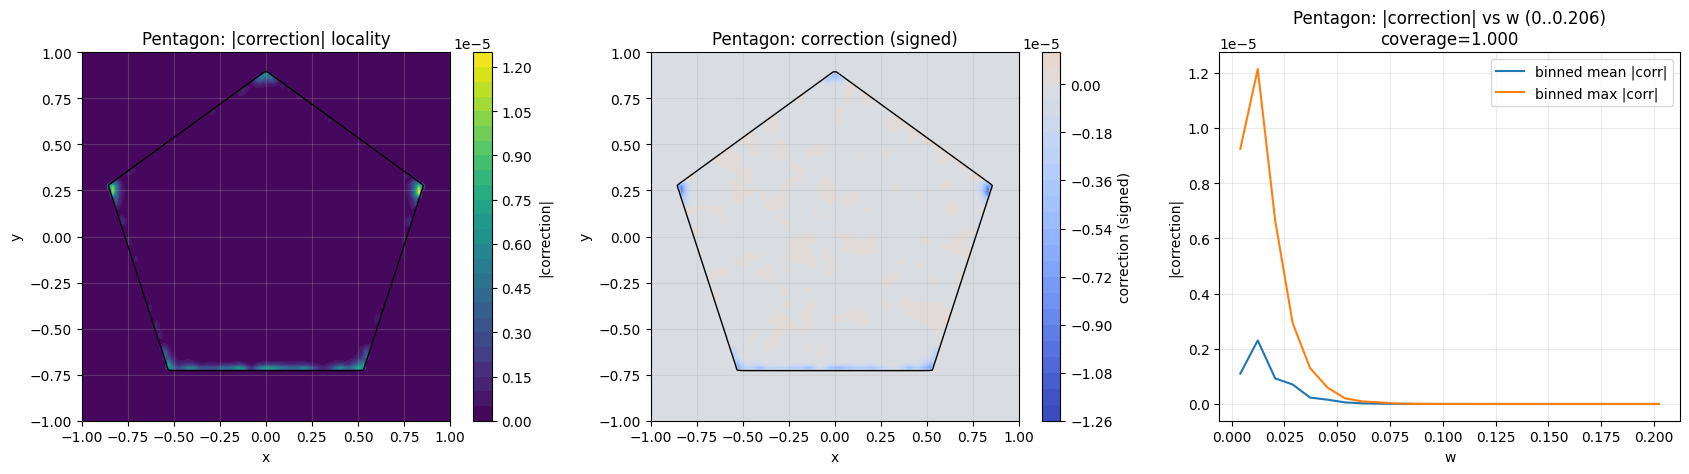

In [37]:
# --- Plot improvement (MAE/L_inf) and correction locality ---

def _metrics_on_inside(u: np.ndarray, u_exact: np.ndarray, inside: np.ndarray):
    err = np.abs(u - u_exact)
    e = err[inside]
    return float(np.mean(e)), float(np.max(e))


# Collect before/after metrics
case_names = list(solved.keys())
mae_before = []
linf_before = []
mae_after = []
linf_after = []

for name in case_names:
    g = grid_by_case[name]
    inside = g["inside"]
    u_exact = g["u_exact"]

    u_before = np.nan_to_num(g["u_num"], nan=0.0)
    u_after = corr_results[name]["u_corrected"]

    m0, l0 = _metrics_on_inside(u_before, u_exact, inside)
    m1, l1 = _metrics_on_inside(u_after, u_exact, inside)

    mae_before.append(m0)
    linf_before.append(l0)
    mae_after.append(m1)
    linf_after.append(l1)

    print(f"{name}: MAE {m0:.3e} -> {m1:.3e} | L_inf {l0:.3e} -> {l1:.3e}")


# Bar plots (before vs after)
x = np.arange(len(case_names))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.bar(x - w/2, mae_before, width=w, label="before")
ax.bar(x + w/2, mae_after, width=w, label="after")
ax.set_xticks(x)
ax.set_xticklabels(case_names)
ax.set_title("MAE improvement")
ax.set_yscale("log")
ax.set_ylabel("MAE (log scale)")
ax.grid(True, alpha=0.25, axis="y")
ax.legend()

ax = axes[1]
ax.bar(x - w/2, linf_before, width=w, label="before")
ax.bar(x + w/2, linf_after, width=w, label="after")
ax.set_xticks(x)
ax.set_xticklabels(case_names)
ax.set_title("L_inf improvement")
ax.set_yscale("log")
ax.set_ylabel("L_inf (log scale)")
ax.grid(True, alpha=0.25, axis="y")
ax.legend()

plt.tight_layout()
plt.show()


# Locality of correction: heatmap of |correction| and binned curves vs w (near-boundary band)
for name in case_names:
    g = grid_by_case[name]
    res = solved[name]
    corr = corr_results[name]["corr"]
    abs_corr = np.abs(corr)

    # bin |corr| by w (similar to error binning)
    bins_corr = bin_errors_by_w(g["w"], abs_corr, g["inside"], w_max=W_NEAR_MAX, n_bins=N_BINS)

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # |correction| heatmap
    ax = axes[0]
    cf = ax.contourf(g["X"], g["Y"], abs_corr, levels=N_CONTOUR_LEVELS, cmap="viridis")
    ax.contour(g["X"], g["Y"], g["w"], levels=[0.0], colors="k", linewidths=1.0)
    fig.colorbar(cf, ax=ax, label="|correction|")
    ax.set_title(f"{name}: |correction| locality")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)

    # signed correction heatmap (optional but useful)
    ax = axes[1]
    vmax = np.nanmax(np.abs(corr))
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1.0
    cf2 = ax.contourf(g["X"], g["Y"], corr, levels=N_CONTOUR_LEVELS, cmap="coolwarm", vmin=-vmax, vmax=vmax)
    ax.contour(g["X"], g["Y"], g["w"], levels=[0.0], colors="k", linewidths=1.0)
    fig.colorbar(cf2, ax=ax, label="correction (signed)")
    ax.set_title(f"{name}: correction (signed)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)

    # binned |corr| vs w
    ax = axes[2]
    ax.plot(bins_corr["centers"], bins_corr["mean"], label="binned mean |corr|")
    ax.plot(bins_corr["centers"], bins_corr["max"], label="binned max |corr|")
    ax.set_title(f"{name}: |correction| vs w (0..{bins_corr['w_clip']:.3g})\ncoverage={bins_corr['coverage']:.3f}")
    ax.set_xlabel("w")
    ax.set_ylabel("|correction|")
    ax.grid(True, alpha=0.25)
    ax.legend()

    plt.tight_layout()
    plt.show()
